# Notebook: Core dynamics

A HORN unit is:

$$\ddot{x} + 2\zeta\omega\,\dot{x} + \omega^2 x = f(x, u), \qquad f(x,u) = W_{rec}\tanh(x) + W_{in}u$$

Here we check that `core.py` implements exactly that. 
Coupling is always off (`W_rec = 0`), making every unit a damped oscillator with a known answer.

The point is to establish that the physics are correct.

**Contents**

1. Free oscillation vs. the analytic solution
2. Damping regimes — under, critical, over
3. Impulse response
4. Sinusoidal drive and steady state
5. Resonance — amplitude and phase against drive frequency
6. A heterogeneous population as a filter bank
7. Why the integrator is semi-implicit

**Units convention.** `core.py` works in rad/s. Everything here is specified in **Hz**, and converted at `w_rads()` / `make_units()` / `drive_sine()`.

In [2]:
import sys
from pathlib import Path

# Make `horn` importable when the notebook is run from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

try:
    import jax
except ModuleNotFoundError:
    import sys, subprocess
    print("jax not found. Trying to install CPU-only jax. If you have a GPU, install the appropriate jaxlib instead.")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "jax[cpu]", "-f",
                               "https://storage.googleapis.com/jax-releases/jax_releases.html"])
    except subprocess.CalledProcessError:
        raise ModuleNotFoundError(
            "Failed to install jax automatically. Please install manually, e.g.:\n"
            "pip install --upgrade 'jax[cpu]' -f https://storage.googleapis.com/jax-releases/jax_releases.html"
        )
    import importlib
    importlib.invalidate_caches()
    import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from horn.core import HORNParams, HORNState, run_sequence, step, energy

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("jax", jax.__version__, jax.devices())

jax 0.11.0 [CpuDevice(id=0)]


Define:

the Hz-> rad/s conversion,

creation of units,

the rest state,

the time vector creation,

the sine_drive in Hz

and a sampling check to accommodate the boundary frequencies without trouble.

In [ ]:
TWOPI = 2 * np.pi

# core.py expects w in in rad/s. But I think in Hz (theta 8, low-gamma 32, high-gamma 80),
# so from here on every frequency the USER types is in Hz, and the 2*pi conversion happens
# in 'make_units', in 'drive_sine', and in 'w_rads()' whenever an analytic formula is evaluated.
#
#   w [rad/s] = 2*pi * f [Hz]        period [s] = 1/f
#   tau       = 1/(zeta*w) = 1/(2*pi*zeta*f)


def w_rads(f_hz):   # Conversion Hz -> rad/s
    return TWOPI * np.asarray(f_hz, dtype=float)


def make_units(n_osc, f_hz, zeta, w_in=0.0, in_size=1):
    """An uncoupled population: W_rec = 0, so each unit is an independent oscillator.

    w_in sets how strongly the external input drives each unit. w_in=0 gives free
    (undriven) motion; w_in=1 means the input IS the forcing term f.
    """
    omega = jnp.broadcast_to(jnp.asarray(w_rads(f_hz), jnp.float32), (n_osc,))  # Hz -> rad/s
    zeta = jnp.broadcast_to(jnp.asarray(zeta, jnp.float32), (n_osc,))
    return HORNParams(
        W_in=jnp.full((n_osc, in_size), w_in, dtype=jnp.float32), # will play with this below with w_in=1
        W_rec=jnp.zeros((n_osc, n_osc)),                          # no coupling, W_rec = 0 for all units
        log_omega=jnp.log(omega),                                 # stored in rad/s, as core.py expects
        log_zeta=jnp.log(zeta),
    )


def at_rest(n_osc, x0=0.0, v0=0.0):
    return HORNState(x=jnp.full((n_osc,), x0), v=jnp.full((n_osc,), v0))


def time_axis(T, dt):
    """run_sequence returns the state AFTER each step, so sample k is at t = (k+1)*dt."""
    return np.arange(1, T + 1) * dt


def drive_sine(f_hz, t):
    """sin(2*pi*f*t) for f in Hz. Broadcasts: f_hz (F,1) with t (1,T) gives (F,T)."""
    return np.sin(TWOPI * np.asarray(f_hz) * t)     # 2*pi turns Hz into phase


# def check_sampling(dt, T, f_max, f_min=None, window_frac=0.5):
#     """Print the two constraints that bracket a usable (dt, T) choice.

#     UPPER bound on dt   : must resolve the FASTEST frequency  -> steps/period >> 1
#     LOWER bound on T*dt : must contain the SLOWEST frequency  -> cycles in window >> 1

#     Raising f_max tightens the first; lowering f_min tightens the second. They pull
#     in opposite directions, and T = duration/dt has to satisfy both at once.
#     """
#     dur = T * dt
#     wdur = dur * window_frac
#     print(f"  record {dur:.2f} s | dt {dt:.1e} | steps/period at {f_max:g} Hz = {1/(f_max*dt):.0f}"
#           + (f" | analysis window {wdur:.2f} s -> {wdur*f_min:.1f} cycles at {f_min:g} Hz"
#              f" (resolves down to {1/wdur:.3f} Hz)" if f_min else ""))


## 1. Free oscillation vs. the analytic solution

For a single unit at $x=1$ with zero velocity and no drive, the exact solution of
$$\ddot{x} + 2\zeta\omega\dot{x} + \omega^2 x = 0$$

is

$$x(t) = e^{-\zeta\omega t}\left[\cos(\omega_d t) + \frac{\zeta\omega}{\omega_d}\sin(\omega_d t)\right],
\qquad \omega_d = \omega\sqrt{1-\zeta^2}$$

Where $\omega_d$, the *damped* frequency, slows the oscillation slightly below $\omega$.

If we would use $\omega$ here, it would produce a slow phase drift, looking as an integrator bug but is
an error in the reference solution.

  tau = 1/(zeta*w0) = 0.0166 s  ->  visibly decayed by ~0.08 s


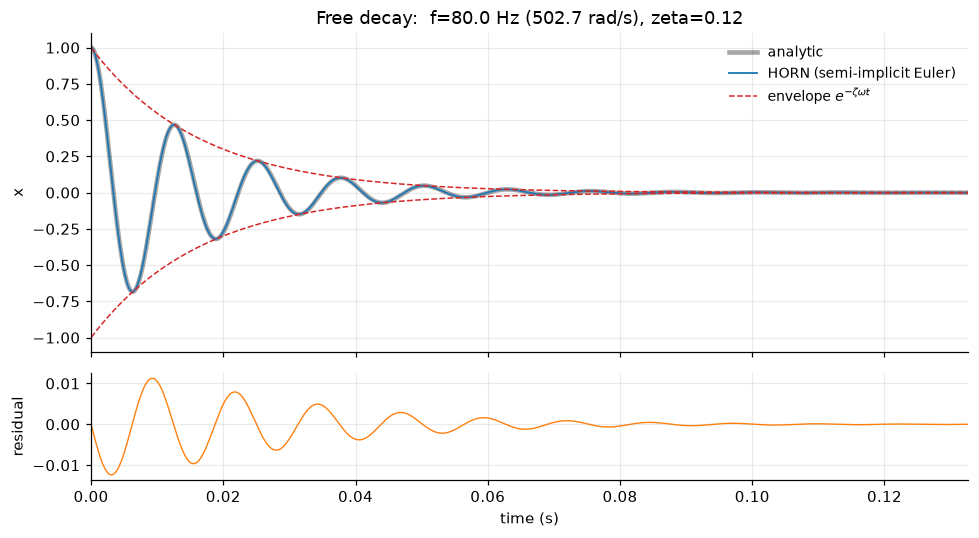

Residual (max |numeric - analytic|) = 1.24e-02
fraction of initial amplitude = 1.24%


In [120]:
f_hz, zeta, dt, T = 80.0, 0.12, 5e-5, 20000  # fs = 1/dt = 20 kHz (low limit for experimental hardware registering spikes)
                                            # theta 8 Hz, low-gamma 32 Hz, high-gamma 80 Hz

w0 = w_rads(f_hz)                  # --> rad/s 
#check_sampling(dt, T, f_max=f_hz)
print(f"  tau = 1/(zeta*w0) = {1/(zeta*w0):.4f} s  ->  visibly decayed by ~{5/(zeta*w0):.2f} s")

p = make_units(1, f_hz, zeta)      
_, xs = run_sequence(p, at_rest(1, x0=1.0), jnp.zeros((T, 1)), dt)
x_num = np.asarray(xs).ravel()      # calculate the damped harmonic oscillator numerically with HORN

t = time_axis(T, dt)
wd = w0 * np.sqrt(1 - zeta**2)     # DAMPED angular frequency, rad/s
x_exact = np.exp(-zeta * w0 * t) * (np.cos(wd * t) + (zeta * w0 / wd) * np.sin(wd * t)) # exact solution

fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(t, x_exact, lw=3, alpha=0.35, color="k", label="analytic")
ax[0].plot(t, x_num, lw=1.2, color="C0", label="HORN (semi-implicit Euler)")
ax[0].plot(t, np.exp(-zeta * w0 * t), ls="--", lw=1, color="C3", label=r"envelope $e^{-\zeta\omega t}$")
ax[0].plot(t, -np.exp(-zeta * w0 * t), ls="--", lw=1, color="C3")
ax[0].set(ylabel="x", title=f"Free decay:  f={f_hz} Hz ({w0:.1f} rad/s), zeta={zeta}")
ax[0].legend(frameon=False, fontsize=9)

ax[1].plot(t, x_num - x_exact, lw=0.9, color="C1")
ax[1].set(xlabel="time (s)", ylabel="residual")
ax[1].set_xlim(0, min(t[-1], 8 / (zeta * w0))) # DISPLAY ONLY. Zoom to the damped region.
plt.tight_layout()
plt.show()

print(f"Residual (max |numeric - analytic|) = {np.max(np.abs(x_num - x_exact)):.2e}") # small, not zero: numerical error
print(f"fraction of initial amplitude = {np.max(np.abs(x_num - x_exact)) / 1.0:.2%}")


The error fraction increases with the omega value (3.1% at 200 Hz) from very low values (0.06% at 4 Hz).

The residual comes from integration error and accumulates with $t$ and scales with `dt`. Halving `dt` should halve the error. We can test it:

In [121]:
print(f"{'dt':>8}  {'steps':>7}  {'max error':>11}   ratio")
prev = None
for dt_i in [2e-3, 1e-3, 5e-4, 2.5e-4, 1.25e-4]:               # time steps to test convergence
    T_i = int(8.0 / dt_i)
    _, xs_i = run_sequence(make_units(1, f_hz, zeta), at_rest(1, x0=1.0),   # f_hz, not w0
                           jnp.zeros((T_i, 1)), dt_i)
    t_i = time_axis(T_i, dt_i)
    # analytic reference uses w0 and wd in rad/s (both defined in the cell above)
    exact_i = np.exp(-zeta * w0 * t_i) * (np.cos(wd * t_i) + (zeta * w0 / wd) * np.sin(wd * t_i))
    err = float(np.max(np.abs(np.asarray(xs_i).ravel() - exact_i)))         # max error for this dt_i
    ratio = "" if prev is None else f"{prev / err:.2f}x"                    # vs previous dt
    print(f"{dt_i:>8.1e}  {T_i:>7d}  {err:>11.3e}   {ratio}")
    prev = err


      dt    steps    max error   ratio
 2.0e-03     4000    6.218e-01   
 1.0e-03     8000    2.721e-01   2.29x
 5.0e-04    16000    1.283e-01   2.12x
 2.5e-04    32000    6.270e-02   2.05x
 1.3e-04    64000    3.105e-02   2.02x


Halves the error each time we halve dt. 

While true at low frequencies for all dts, it is less approximate for high frequencies at big dt (1e-3 at 80 Hz makes 2.29x from 2e-3). 

## 2. Damping regimes

$\zeta$ is the parameter that makes an oscillator a *memory* rather than just a filter.
It sets how long the ringing survives, so it is the closest thing HORN has to a forget gate,
except it is a physical constant of the unit rather than a learned function of the input.

- $\zeta < 1$ **underdamped**: oscillates, envelope decays as $e^{-\zeta\omega t}$ and too low would make it too persistent
- $\zeta = 1$ **critically damped**: fastest return to zero with no overshoot
- $\zeta > 1$ **overdamped**: crawls to zero, never crosses it

We have seen this in the demo already, but we can add the tau (time constant):

$$\tau = \frac{1}{\zeta\omega} = \frac{1}{2\pi\zeta f}$$

so the effective memory horizon is set by the *product*.

An 8 Hz unit at $\zeta=0.2$ has $\tau \approx 0.1$ s.

Fast and slow oscillators with the same dumping do **not** remember for the same length of time.

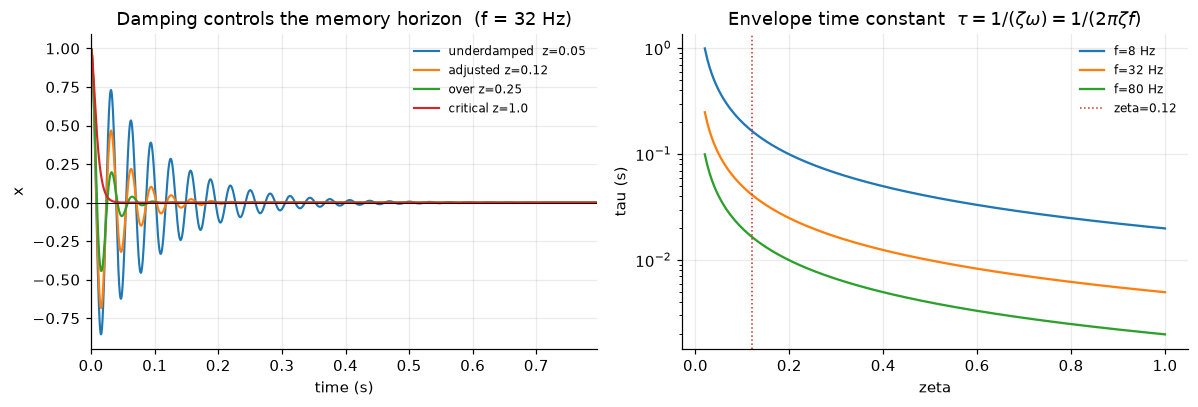

In [136]:
f_hz, dt, T = 32.0, 5e-5, 40000   # 32 Hz = low-gamma. Hz throughout.
w0 = w_rads(f_hz)
#check_sampling(dt, T, f_max=f_hz)
t = time_axis(T, dt)
regimes = [(0.05, "underdamped  z=0.05"),
           (0.12, "adjusted z=0.12"),  # this approximates a low-gamma burst
           (0.25, "over z=0.25"),
           (1.00, "critical z=1.0")]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for i, (z, label) in enumerate(regimes):
    _, xs = run_sequence(make_units(1, f_hz, z), at_rest(1, x0=1.0), jnp.zeros((T, 1)), dt)
    ax[0].plot(t, np.asarray(xs).ravel(), lw=1.4, label=label, color=f"C{i}")
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set(title=f"Damping controls the memory horizon  (f = {f_hz:g} Hz)",
          xlabel="time (s)", ylabel="x")
ax[0].set_xlim(0, min(t[-1], 8 / (0.05 * w0))) # DISPLAY ONLY, zoom in
ax[0].legend(fontsize=8, frameon=False)

zs = np.linspace(0.02, 1.0, 200)
for f_band in [8.0, 32.0, 80.0]:                      # theta, low-gamma, high-gamma
    ax[1].plot(zs, 1.0 / (zs * w_rads(f_band)), label=f"f={f_band:.0f} Hz")
ax[1].axvline(regimes[1][0], color="C3", ls=":", lw=1, label=f"zeta={regimes[1][0]:.2f}")
ax[1].set(title=r"Envelope time constant  $\tau = 1/(\zeta\omega) = 1/(2\pi\zeta f)$",
          xlabel="zeta", ylabel="tau (s)", yscale="log")
ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


## 3. Impulse response

That was for the free decay testing.

To test the *drive* we need forcing it, with **impulse**.

A sinlge impulse of $1/\Delta t$ at the first step delivers momentum.
Under semi-implicit Euler this is exactly: 

$$\Delta t \cdot (1/\Delta t) = 1$$

so the unit is kicked to $v = 1$ and then evolves freely. The analytic impulse response is:

$$h(t) = \frac{1}{\omega_d}e^{-\zeta\omega t}\sin(\omega_d t)$$

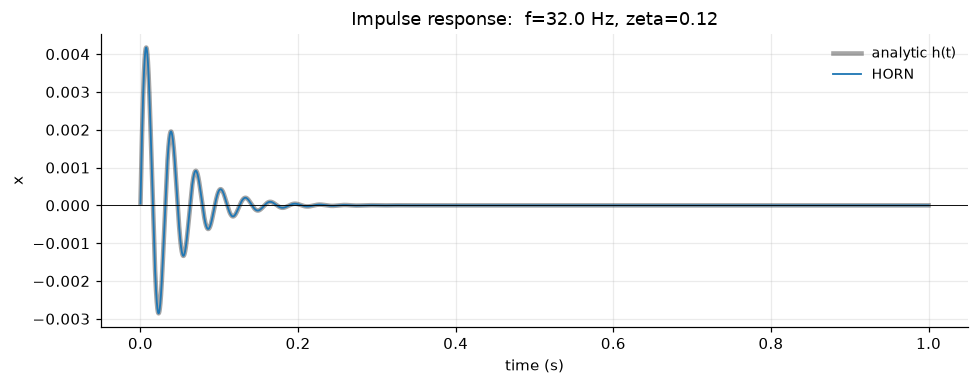

max |numeric - analytic| = 9.15e-06
relative to peak response = 0.22%


In [137]:
f_hz, zeta, dt, T = 32.0, 0.12, 5e-5, 20000     # Hz
w0 = w_rads(f_hz)
#check_sampling(dt, T, f_max=f_hz)

u = jnp.zeros((T, 1)).at[0, 0].set(1.0 / dt)      # unit-area impulse at t=0
p = make_units(1, f_hz, zeta, w_in=1.0)           # w_in=1 -> the input IS the whole impulse term
_, xs = run_sequence(p, at_rest(1), u, dt)
x_num = np.asarray(xs).ravel()

t = time_axis(T, dt)
wd = w0 * np.sqrt(1 - zeta**2)                    # rad/s
h_exact = np.exp(-zeta * w0 * t) * np.sin(wd * t) / wd   # note the 1/wd: amplitude scales with rad/s

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(t, h_exact, lw=3, alpha=0.35, color="k", label="analytic h(t)")
ax.plot(t, x_num, lw=1.2, color="C0", label="HORN")
ax.axhline(0, color="k", lw=0.6)
ax.set(xlabel="time (s)", ylabel="x", title=f"Impulse response:  f={f_hz} Hz, zeta={zeta}")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(f"max |numeric - analytic| = {np.max(np.abs(x_num - h_exact)):.2e}")
print(f"relative to peak response = {np.max(np.abs(x_num - h_exact)) / np.max(np.abs(h_exact)):.2%}")


Therefore *"persistence is free"*. Meaning that one kick, and the unit carries a decaying record of it for
$\sim 1/(\zeta\omega) \approx 2.5$ s, 

No need for nothing to be trained to make it happen.

The effect is bigger as the damping increases. Low damping makes the impulse response less different from a simple decay.

## 4. Sinusoidal drive and steady state

Now drive them with a sinusoidal input: $u(t) = \sin(\Omega t)$. 

The response splits into a transient (the homogeneous solution, decaying at $e^{-\zeta\omega t}$) 

and a steady state at the *drive* frequency $\Omega$, not the natural frequency:

$$x_{ss}(t) = A(\Omega)\sin(\Omega t - \phi(\Omega)), \qquad
A = \frac{1}{\sqrt{(\omega^2-\Omega^2)^2 + (2\zeta\omega\Omega)^2}}, \qquad
\phi = \arctan\frac{2\zeta\omega\Omega}{\omega^2-\Omega^2}$$

Three drive frequencies: under resonance (now theta), at resonance (now low-gamma), and above (now high gamma). 

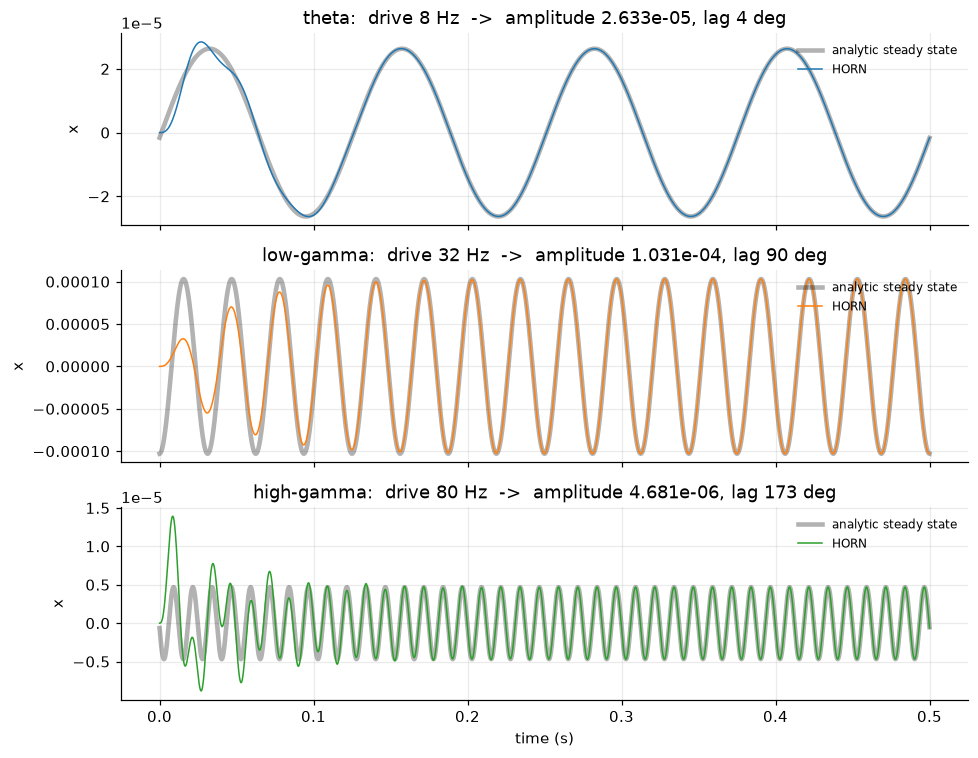

In [138]:
f_hz, zeta, dt, T = 32.0, 0.12, 5e-5, 10000   # unit natural frequency 32 Hz (low-gamma)
w0 = w_rads(f_hz)
t = time_axis(T, dt)

def analytic_ss(Om, w0, z):
    """Steady-state amplitude and phase lag. Om and w0 must BOTH be in rad/s."""
    A = 1.0 / np.sqrt((w0**2 - Om**2) ** 2 + (2 * z * w0 * Om) ** 2)
    phi = np.arctan2(2 * z * w0 * Om, w0**2 - Om**2)
    return A, phi

drives = [(8.0, "theta"), (32.0, "low-gamma"), (80.0, "high-gamma")]   # drive frequencies in Hz
fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

for i, (fd_hz, label) in enumerate(drives):
    #check_sampling(dt, T, f_max=fd_hz)
    Om = w_rads(fd_hz)                                    # Hz -> rad/s for the formulas
    u = jnp.asarray(drive_sine(fd_hz, t))[:, None]        # sin(2*pi*fd*t)
    _, xs = run_sequence(make_units(1, f_hz, zeta, w_in=1.0), at_rest(1), u, dt)
    x_num = np.asarray(xs).ravel()

    A, phi = analytic_ss(Om, w0, zeta)
    ax[i].plot(t, A * np.sin(Om * t - phi), lw=3, alpha=0.3, color="k",   # rad/s inside sin()
               label="analytic steady state")
    ax[i].plot(t, x_num, lw=1.0, color=f"C{i}", label="HORN")
    ax[i].set(ylabel="x",
              title=f"{label}:  drive {fd_hz:g} Hz  ->  amplitude {A:.3e}, lag {np.degrees(phi):.0f} deg")
    ax[i].legend(fontsize=8, frameon=False, loc="upper right")

ax[-1].set(xlabel="time (s)")
plt.tight_layout()
plt.show()


**The transient is visible only for a short time.** After roughly $5/(\zeta\omega)$ the
numeric trace lies on the analytic solution. That transit time is exactly **the memory horizon** from before.

**Resonance is a large effect.** At $\Omega = \omega$ the amplitude is $\sim 1/(2\zeta\omega^2)$,
which for $\zeta = 0.1$ is more than an order of magnitude above the off-resonance response. Here I set zeta bigger, so the magnitude is not so big.

An oscillator is **selective** for its own frequency and making it a functional "filter".

## 5. Resonance: amplitude and phase against drive frequency

Now the drive is a *sweeping* $\Omega$ (a chirp). Measuring the steady-state amplitude gives the unit's transfer function.

Makes the **selectivity** of the oscillators into a **measurement**, where $\zeta$ sets the *width* of the resonance
peak as well as the decay time. 

**Low** $\zeta$ means long memory and narrow tuning.

Amplitude and phase are extracted by projecting the steady-state segment onto $\sin\Omega t$
and $\cos\Omega t$, with a Hann window to suppress spectral leakages.

Note: `jax.vmap` Python loops over separate runs.\n\nAll frequencies below are in **Hz**; the conversion to rad/s happens inside `w_rads()` before every analytic formula, and inside the drive and the projection basis.

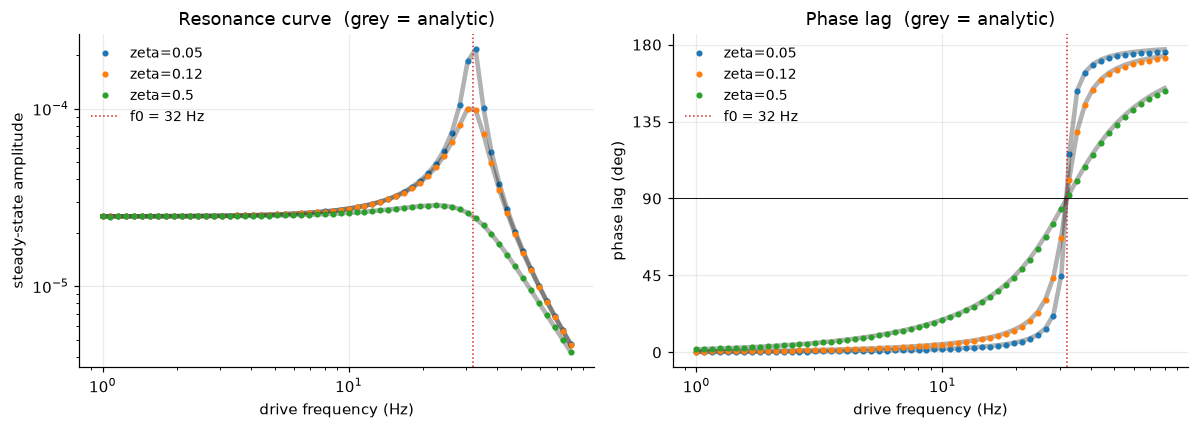

In [139]:
dt, T = 5e-5, 100000         # for a total time of 5 s
f0_hz = 32.0                  # natural frequency of the unit under test, in Hz
w0 = w_rads(f0_hz)
freqs = np.logspace(np.log10(1.0), np.log10(80.0), 60)   # drive frequencies in Hz, log-spaced
tt = np.arange(1, T + 1) * dt

start = T // 2               # measure over the second half only, at secured steady state
win = np.hanning(T - start)
#check_sampling(dt, T, f_max=freqs[-1], f_min=freqs[0])

def measure(zeta):
    p = make_units(1, f0_hz, zeta, w_in=1.0)
    Om = w_rads(freqs)[:, None]                                        # (F,1) rad/s
    U = jnp.asarray(np.sin(Om * tt[None, :])[..., None])               # (F, T, 1)
    run = lambda u: run_sequence(p, at_rest(1), u, dt)[1][:, 0]        # -> (T,)
    xs = np.asarray(jax.vmap(run)(U))                                  # (F, T)

    seg, ts = xs[:, start:], tt[start:]
    norm = win.sum()
    # the projection basis MUST match the drive, so it carries the same 2*pi
    s = 2 * np.sum(win * seg * np.sin(Om * ts[None, :]), axis=1) / norm
    c = 2 * np.sum(win * seg * np.cos(Om * ts[None, :]), axis=1) / norm
    return np.hypot(s, c), np.unwrap(np.arctan2(-c, s))   # amplitude, phase lag

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, z in enumerate([0.05, 0.12, 0.50]):                # dampings to test (zetas)
    amp, phase = measure(z)
    Om = w_rads(freqs)                                    # rad/s for the analytic curves
    A_ex = 1.0 / np.sqrt((w0**2 - Om**2) ** 2 + (2 * z * w0 * Om) ** 2)
    phi_ex = np.arctan2(2 * z * w0 * Om, w0**2 - Om**2)

    ax[0].loglog(freqs, A_ex, lw=3, alpha=0.3, color="k")     # x axis stays in Hz
    ax[0].loglog(freqs, amp, "o", ms=3, color=f"C{i}", label=f"zeta={z}")
    ax[1].semilogx(freqs, np.degrees(phi_ex), lw=3, alpha=0.3, color="k")
    ax[1].semilogx(freqs, np.degrees(phase), "o", ms=3, color=f"C{i}", label=f"zeta={z}")

ax[0].axvline(f0_hz, color="C3", ls=":", lw=1, label=f"f0 = {f0_hz:g} Hz")  
ax[0].set(xlabel="drive frequency (Hz)", ylabel="steady-state amplitude",
          title="Resonance curve  (grey = analytic)")
ax[0].legend(frameon=False, fontsize=9)

ax[1].axvline(f0_hz, color="C3", ls=":", lw=1, label=f"f0 = {f0_hz:g} Hz")
ax[1].axhline(90, color="k", lw=0.6)
ax[1].set(xlabel="drive frequency (Hz)", ylabel="phase lag (deg)",
          title="Phase lag  (grey = analytic)", yticks=[0, 45, 90, 135, 180])
ax[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


The phase panel shows something about the state that no conventional RNN has an equivalent for.

Below resonance: the unit follows the drive almost in step.

At $\Omega = \omega$ the lag is exactly $90°$ **for every value of $\zeta$**, damping changes how sharp the transition is, not where it sits.

Above resonance: the unit goes into antiphase, moving opposite to the driver.

So a population with heterogeneous $\omega$ responds to a single input with a *spread of phases*
determined by how each unit's natural frequency compares to the input.

Information is encoded in **relative phase** across the population, **not only in amplitude**.

## 6. A heterogeneous population as a filter bank

Four uncoupled units at $f = 8, 32, 80, 150$ Hz (theta, low-gamma, high-gamma, ripple) driven by a
linear chirp sweeping $2 \to 160$ Hz. Each unit should light up as the sweep passes its own natural
frequency, and fall quiet again afterwards.

This time each band gets **its own $\zeta$** (0.20, 0.12, 0.10, 0.09) rather than one shared value,
which changes the outcome more than it might appear.

The population collectively performs a time-frequency decomposition of the input, by design and
with no learning needed.


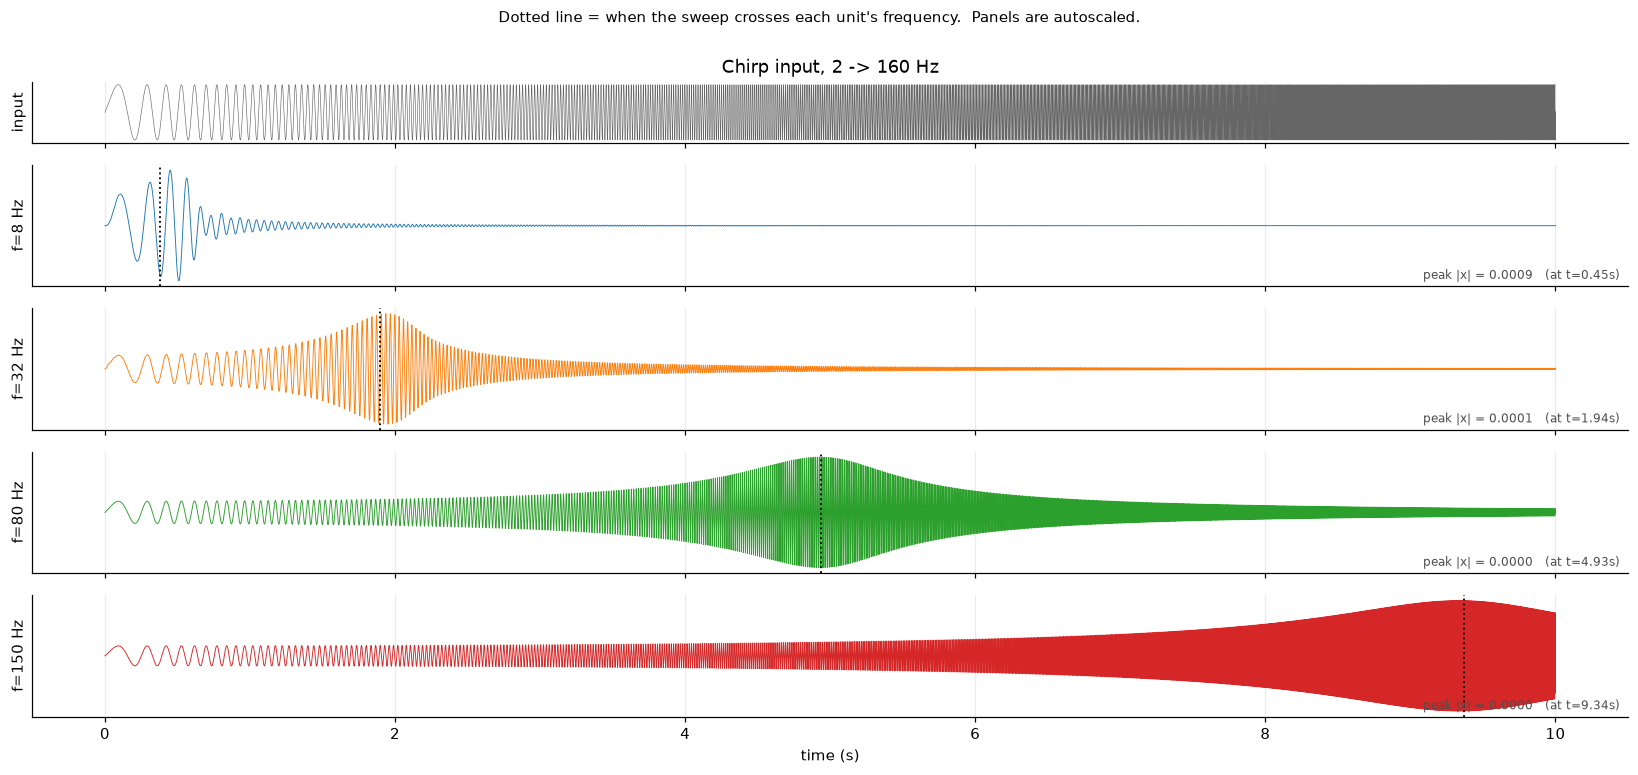

 f (Hz)   peak |x|  steady-state   reached  dwell/build-up
      8    0.00087       0.00099      88%            2.04
     32    0.00010       0.00010      99%           11.73
     80    0.00002       0.00002     100%           50.90
    150    0.00001       0.00001     100%          144.95


In [141]:
dt, T = 5e-5, 200000                               # 10 s total
t = np.arange(1, T + 1) * dt
f0, f1 = 2.0, 160.0                                 # chirp limits in Hz
inst_freq = f0 + (f1 - f0) * t / t[-1]             # instantaneous frequency, Hz
chirp = np.sin(TWOPI * np.cumsum(inst_freq) * dt)

bands_hz = jnp.array([8.0, 32.0, 80.0, 150.0])      # unit natural frequencies, Hz
zeta_c = jnp.array([0.2, 0.12, 0.10, 0.09])           # damping ratios
p = make_units(4, bands_hz, zeta_c, w_in=1.0)
#check_sampling(dt, T, f_max=float(f1))
_, xs = run_sequence(p, at_rest(4), jnp.asarray(chirp)[:, None], dt)
xs = np.asarray(xs)

fig, ax = plt.subplots(5, 1, figsize=(15, 7), sharex=True,
                       gridspec_kw={"height_ratios": [1, 2, 2, 2, 2]})
ax[0].plot(t, chirp, lw=0.4, color="0.4")
ax[0].set(ylabel="input", title=f"Chirp input, {f0:g} -> {f1:g} Hz")
ax[0].set_yticks([])

for i, f_b in enumerate(np.asarray(bands_hz)):
    ax[i + 1].plot(t, xs[:, i], lw=0.6, color=f"C{i}")
    t_hit = (f_b - f0) / (f1 - f0) * t[-1]         # when the sweep crosses this unit's f (Hz space)
    ax[i + 1].axvline(t_hit, color="black", ls=":", lw=1.2)
    peak = np.max(np.abs(xs[:, i]))
    t_peak = t[np.argmax(np.abs(xs[:, i]))]
    ax[i + 1].set(ylabel=f"f={f_b:.0f} Hz")
    ax[i + 1].set_yticks([])
    ax[i + 1].text(0.995, 0.06, f"peak |x| = {peak:.4f}   (at t={t_peak:.2f}s)",
                   transform=ax[i + 1].transAxes, ha="right", fontsize=8, color="0.3")

ax[-1].set(xlabel="time (s)")
fig.suptitle("Dotted line = when the sweep crosses each unit's frequency.  "
             "Panels are autoscaled.", y=1.0, fontsize=10)
plt.tight_layout()
plt.show()

sweep_rate = (f1 - f0) / t[-1]                     # Hz per second

print(f"{'f (Hz)':>7} {'peak |x|':>10} {'steady-state':>13} {'reached':>9} "
      f"{'dwell/build-up':>15}")
for i, f_b in enumerate(np.asarray(bands_hz)):
    peak = np.max(np.abs(xs[:, i]))
    w_b = w_rads(f_b)                              # rad/s
    ss = 1 / (2 * zeta_c[i] * w_b**2)                 # steady-state resonant amplitude 1/(2*zeta*w^2)
    dwell = 2 * zeta_c[i] * f_b / sweep_rate          # s. Peak half-width ~2*zeta*f in Hz / (Hz per s)
    build = 1 / (zeta_c[i] * w_b)                     # s. Fill-up time tau = 1/(zeta*w), rad/s
    print(f"{f_b:>7.0f} {peak:>10.5f} {ss:>13.5f} {peak / ss:>8.0%} {dwell / build:>15.2f}")


**The peak arrives after the crossing.** Each unit lags the moment the sweep passes its
natural frequency, and keeps ringing after the sweep is gone. That lag **is** the memory,
seen in the time domain. It is $\tau = 1/(\zeta\omega)$: 99 ms for the 8 Hz unit down to 12 ms
for the 150 Hz one.

**Giving each band its own $\zeta$ fixes two problems:**

*Amplitude.* Steady-state resonant amplitude is $1/(2\zeta\omega^2)$. Before, with a shared $\zeta$ the
spread from 8 to 150 Hz would be $(150/8)^2 = 352\times$. Damping the slow units harder
(0.20) than the fast ones (0.09) cuts it to $158\times$. The readout still sees a wide dynamic
range, but 2.2 times less of one, just by choosing $\zeta$ per band.

*Tracking.* The dwell/build-up column is
$$\frac{\text{dwell}}{\text{build-up}} = \frac{4\pi(\zeta f)^2}{\text{sweep rate}}$$
so it depends on the **product** $\zeta f$, not on $f$ alone. That is the lever. Previously, with a
single small $\zeta$, the slowest unit had a ratio below 1 and reached only a fraction of its
steady state. Now every ratio exceeds 1 and every unit reaches at least 88% — the 8 Hz unit is the
only one not essentially saturated, and even it is close.

**For the the nested-oscillation...** The number of cycles a unit rings for is
$$N_{\text{cycles}} = f\tau = \frac{1}{2\pi\zeta}$$
which depends on $\zeta$ **only**. So $\zeta$ sets memory measured in *cycles*,
while $\omega$ sets memory measured in *seconds*. These $\zeta$ values give 0.8, 1.3, 1.6 and 1.8
cycles respectively.

Roughly right at the gamma end, far too
damped at theta end: hippocampal theta sustains over many cycles, not 0.8. Reproducing that would
need $\zeta \approx 0.04$ for the 8 Hz unit — which would push its amplitude back up and undo the
dynamic-range compression above.

**So $\zeta$ cannot serve two masters.** It is simultaneously the memory-in-cycles knob and the
amplitude-normalisation knob, and the biologically motivated value fights the numerically convenient
one. For the nested architecture that argues for decoupling them: keep $\zeta$ free to match the
biology of each band, and handle the readout scale mismatch somewhere else — an $\omega$-dependent
initialisation of $W_{in}$, or a per-unit output gain.

For the next notebook: with heterogeneous $\omega$ the readout sees mismatched scales, so gradient
magnitudes will differ substantially between slow and fast oscillators. Either $W_{in}$ learns to
compensate, or the quiet units are effectively ignored. Worth testing whether an $\omega$-dependent
initialisation fixes it, and whether sequence length interacts with which units end up useful.


## Conclusion

HORN is verified against closed-form solutions: free decay, impulse response, steady-state amplitude
and phase across frequency. Convergence in `dt` confirmed.

To carry:

1. **`dt` must sit well below the period of the fastest unit.** With heterogeneous $\omega$ the
   constraint is set by $\omega_{max}$, so adding fast units silently raises the cost of every
   sequence. A learned $\omega$ that drifts upward during training can therefore destabilise
   integration without any parameter doing anything obviously wrong.
2. **Response amplitude scales as $1/(2\zeta\omega^2)$.** Fast units are quiet ones, so heterogeneous
   populations start scale-mismatched at the readout. Per-band $\zeta$ compresses this — 352x down to
   158x across 8-150 Hz — but only partially, and it spends $\zeta$ on a job that memory horizon also
   needs it for.
3. **Memory horizon is $1/(\zeta\omega)$, not $1/\zeta$.** In seconds it depends on both; in *cycles*
   it is $1/(2\pi\zeta)$ and depends on $\zeta$ alone. Whatever range of memory horizons a task needs
   has to be reachable from the $(\omega, \zeta)$ pairs at initialisation, because gradient descent
   through oscillatory dynamics is not reliable at moving them far.
4. **A unit's ability to track a moving input goes as $(\zeta f)^2$.** Slow, lightly damped units
   cannot keep up with a fast sweep and never reach steady state. This is a property of the
   $\zeta f$ product, not of frequency alone.
